# Time taken to adapt to a cocktail

In [1]:
from scipy.stats import pearsonr, spearmanr
spearmanr([1,2],[1,2])

SignificanceResult(statistic=0.9999999999999999, pvalue=nan)

In [2]:
import os
import sys
import torch
from itertools import product
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D
from scipy.stats import pearsonr
from matplotlib import cm
from adjustText import adjust_text
import matplotlib as mpl
import re
import math

from tqdm import tqdm

main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils

os.chdir('../covid')
from global_variables import *
from utils_evaluate_seq import *
os.chdir('../mean_field_theory')

from utils_mean_field import *
from utils_rbm_mean_field import *

e:\ESCAPE_PATHS\mean_field_theory\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\mean_field_theory\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights


Loaded 29 KD vectors


C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [3]:
PROT_INIT = Proteins_utils.load_FASTA("../covid/exp_data/wt_omicron.fasta")[0]
PROT_INIT = PROT_INIT[BEGIN:-END]


In [4]:
L=PROT_INIT.shape[0]
Q = 20

In [5]:
ab_names= list(ESCAPE_VECTORS.keys())
ab_focused = ["REGN10933", "REGN10987",'LY-CoV555','LY-CoV016']
indexes_abs = [ab_names.index(ab) for ab in ab_focused]
ab_names

['COV2-2050',
 'COV2-2082',
 'COV2-2094',
 'COV2-2096',
 'COV2-2130',
 'COV2-2165',
 'COV2-2196',
 'COV2-2479',
 'COV2-2499',
 'COV2-2677',
 'COV2-2832',
 'CR3022',
 'LY-CoV016',
 'LY-CoV555',
 'REGN10933',
 'REGN10987',
 'S2D106',
 'S2E12',
 'S2H13',
 'S2H14',
 'S2H58',
 'S2H97',
 'S2X16',
 'S2X227',
 'S2X259',
 'S2X35',
 'S2X58',
 'S304',
 'S309']

In [6]:
os.listdir('results_scripts')

['all_cocktails', 'cocktails_beta', 'covid_D_20', 'covid_D_20_ba1', 'lattice']

# Order params

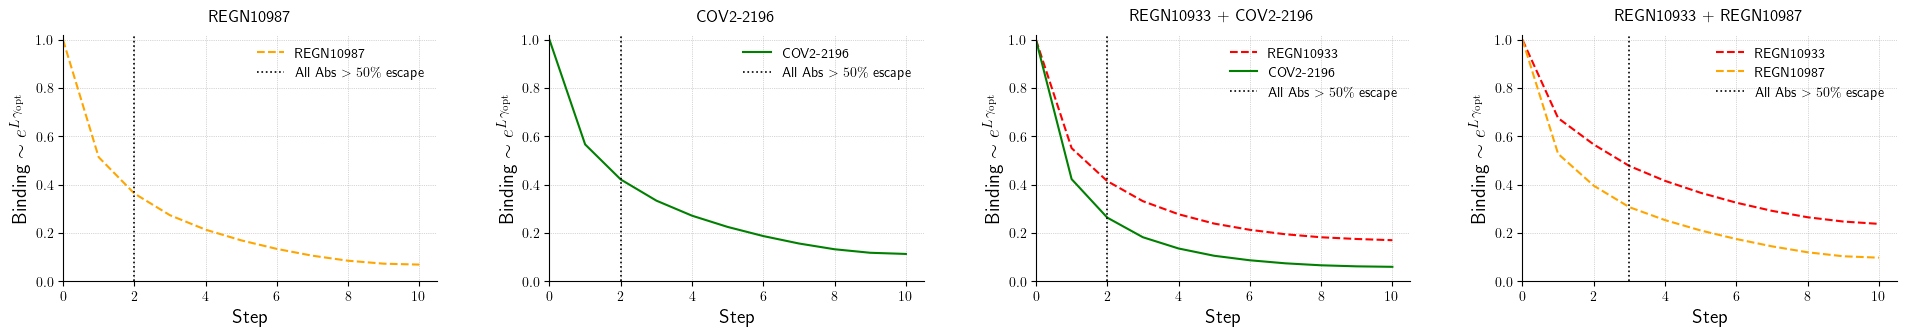

In [8]:




style_dict = {
    "REGN10933": {"color": "red", "linestyle": "--"},
    "REGN10987": {"color": "orange", "linestyle": "--"},
    "LY-CoV555": {"color": "deepskyblue", "linestyle": "-"},
    "LY-CoV016": {"color": "darkblue", "linestyle": "-"},
    "COV2-2196": {"color": "green", "linestyle": "-"},
}

# Setup
dir = 'results_scripts/cocktails_beta'
BETA_AB = 1
D = 1

def extract_parameters(path):
    beta_ab_match = re.search(r'beta_ab_(\d+(?:\.\d+)?)', path)
    D_match = re.search(r'D_(\d+)', path)
    ab_parts = path.split('ab_')
    condition = ab_parts[3] if len(ab_parts) > 3 else None
    return {
        "beta_ab": float(beta_ab_match.group(1)) if beta_ab_match else None,
        "D": int(D_match.group(1)) if D_match else None,
        "condition": condition
    }

condition_sets = [
    ["REGN10987", "COV2-2196", "REGN10933_COV2-2196"],
    ["REGN10933_REGN10987"],
]

# Get all folders
all_dirs = [d for d in os.listdir(dir) if os.path.isdir(os.path.join(dir, d))]

paths = []
labels = []

for condition_set in condition_sets:
    for condition in condition_set:
        for d in all_dirs:
            params = extract_parameters(d)
            if (
                params["beta_ab"] == BETA_AB and
                params["D"] == D and
                params["condition"] == condition
            ):
                paths.append(d)
                labels.append(condition)
                break 

# --- PLOTTING SECTION ---

mpl.rcParams.update({
    "text.usetex": True,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14
})

n_paths = len(labels)
n_cols = 4
n_rows = math.ceil(n_paths / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, condition in enumerate(labels):
    abs_involved = condition.split("_") if "_" in condition else [condition]

    # Load data
    mopt = np.exp(np.load(os.path.join(dir, paths[i], "mopt.npy"))[:, :])

    ax = axes[i]

    # Plot each antibody
    for ab in abs_involved:
        # Note: Ensure 'ab_names' is defined in your global scope
        ab_idx = ab_names.index(ab)
        ax.plot(mopt[:, ab_idx],
                label=ab,
                color=style_dict[ab]["color"],
                linestyle=style_dict[ab]["linestyle"],
                linewidth=1.5)

    # --- MODIFIED SECTION START ---
    # Logic: Find the step where ALL involved antibodies have binding < 0.5
    indices = [ab_names.index(ab) for ab in abs_involved]
    
    # Check if all columns (antibodies) are < 0.5 at each step
    # axis=1 checks across antibodies for a specific time step
    all_escaped = np.all(mopt[:, indices] < 0.5, axis=1)
    
    # Find the first index where this is True
    cross_idx = np.argmax(all_escaped) if np.any(all_escaped) else None
    
    if cross_idx is not None:
        ax.axvline(cross_idx, color="black", linestyle=":", linewidth=1.2, label=r"All Abs $>50\%$ escape")
    # --- MODIFIED SECTION END ---

    # Format subplot
    ax.set_title(condition.replace("_", " + "), pad=10)
    ax.set_xlabel(r"Step", fontsize=14)
    ax.set_ylabel(r"Binding $\sim e^{L\, \gamma_{\mathrm{opt}}}$", fontsize=14)
    ax.set_ylim(0, 1.02)
    ax.set_xlim(left=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, which='major', linestyle=':', linewidth=0.5)
    ax.legend(frameon=False, loc='upper right')

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1.2)
plt.subplots_adjust(hspace=0.35, wspace=0.3)
plt.show()

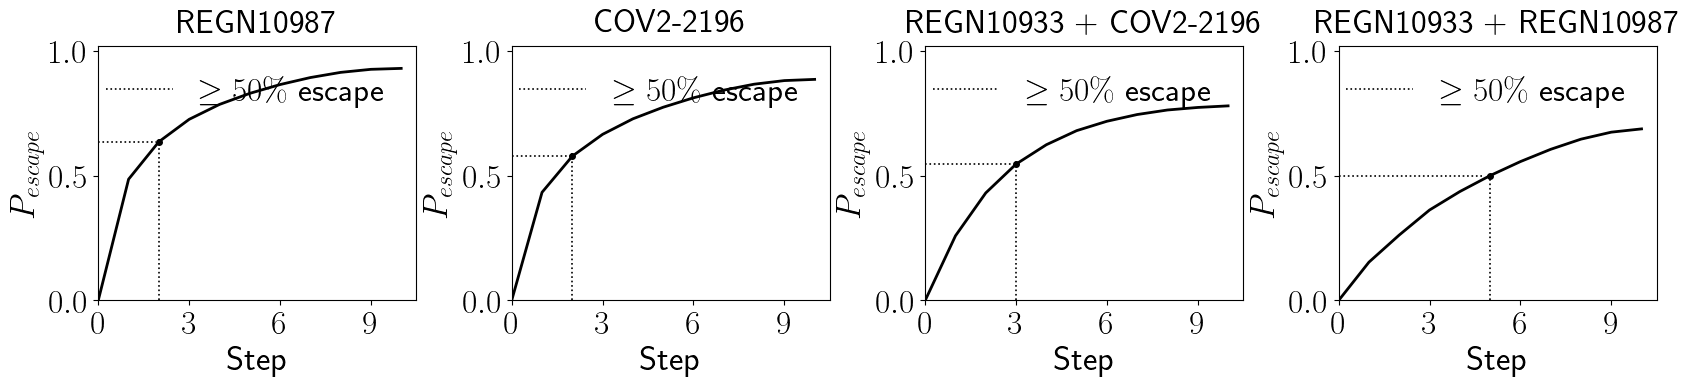

In [9]:

# LaTeX formatting
mpl.rcParams.update({
    "text.usetex": True,
    "axes.titlesize": 24,
    "xtick.labelsize": 24,
    "ytick.labelsize": 24,
    "legend.fontsize": 24,
    "figure.titlesize": 20
})

# Layout
n_paths = len(labels)
n_cols = 4
n_rows = math.ceil(n_paths / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, condition in enumerate(labels):
    abs_involved = condition.split("_") if "_" in condition else [condition]

    # Load data
    mopt = np.exp(np.load(os.path.join(dir, paths[i], "mopt.npy"))[:, :] )

    ax = axes[i]

    # Compute antibody fitness: product over (1 - mopt_i)
    indices = [ab_names.index(ab) for ab in abs_involved]
    fitness = np.prod(1 - mopt[:, indices], axis=1)

    # Plot fitness curve
    ax.plot(fitness,
            color="black",
            linestyle="-",
            linewidth=2)


    # Mark 50% escape threshold with crosshairs
    cross_idx = np.argmax(fitness > 0.5) if np.any(fitness > 0.5) else None
    if cross_idx is not None:
        fitness_val = fitness[cross_idx]
        ax.axvline(cross_idx, ymax=fitness_val, color="black", linestyle=":", linewidth=1.2)
        ax.axhline(fitness_val, xmax=cross_idx / len(fitness), color="black", linestyle=":", linewidth=1.2)
        ax.plot(cross_idx, fitness_val, marker='o', color='black', markersize=4)


    # Format subplot
    ax.set_title(condition.replace("_", " + "), pad=10)
    ax.set_xlabel(r"Step", fontsize=25)
    ax.set_ylabel(r"$P_{escape}$", fontsize=25)
    ax.set_ylim(0, 1.02)
    ax.set_xlim(left=0)
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    # ax.grid(True, which='major', linestyle=':', linewidth=0.5)
    ax.set_xticks(np.arange(0, len(fitness), 3))

    # Add dashed line to legend
    ax.plot([], [], color="black", linestyle=":", linewidth=1.2, label=r"$\geq 50\%$ escape")

    ax.legend(frameon=False, loc='upper right')

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1.2)
plt.subplots_adjust(hspace=0.35, wspace=0.3)
plt.show()


# RBM energy at escape step

In [10]:



PROT_INIT = Proteins_utils.load_FASTA("../covid/exp_data/wt_omicron.fasta")[0]
PROT_INIT = PROT_INIT[BEGIN:-END]


# %%
L = PROT_INIT.shape[0]
Q = 20


gamma_f_list = create_gamma_functions(
    torch.tensor(RBM.hlayer.gamma_plus),
    torch.tensor(RBM.hlayer.gamma_minus),
    torch.tensor(RBM.hlayer.theta_plus),
    torch.tensor(RBM.hlayer.theta_minus),
    L,
)


# Combine weights and functions
selection_coeff_list = []
selection_coeff_list_gamma_only = []
selection_coeff_list_gamma_only.extend(create_ab_functions(n_ab=29, beta_ab=0, L=L))
selection_coeff_list_gamma_only.extend(gamma_f_list)

selection_coeff_list.extend(create_ab_functions(n_ab=29, beta_ab=1, L=L))
selection_coeff_list.extend(gamma_f_list)


# Antibody weights
ab_names = list(ESCAPE_VECTORS.keys())
wab = np.zeros((L, Q, len(ab_names)))
for idx, ab in enumerate(ab_names):
    w_ab = ESCAPE_VECTORS[ab].reshape(L, Q)  # "no bias"
    wab[:, :, idx] = w_ab

# make sure only<=0 coeffs
for i in range(len(ab_names)):
    if np.any(wab[:, :, i] > 0):
        raise ValueError(f"Escape vector {ab_names[i]} has positive coeffs")

# RBM weights
wgamma = np.transpose(RBM.weights[:, :, :], (1, 2, 0))
g = RBM.vlayer.fields


w_components = []
w_components.append(wab)
w_components.append(wgamma)
w = np.concatenate(w_components, axis=-1)


# %%


def get_zeta(mopt, selection_coeff_list_gamma_only):
    """
    returns potential of gamma and ab
    """
    zeta_values_gamma_only = []

    for j in range(mopt.shape[0]):

        zeta_values_gamma_only.append(
            Zeta(torch.tensor(mopt[j]), selection_coeff_list_gamma_only, L)
            .detach()
            .numpy()
        )
    zeta_values_gamma_only = np.array(zeta_values_gamma_only)
    return zeta_values_gamma_only
        # zeta_values - zeta_values_gamma_only,
      # gamma potential, Ab potential


def get_phi(qopt, q_c):
    phi_values = Phi_cont(torch.tensor(qopt), q_c, L).detach().numpy()
    return phi_values


def get_field(path_proba):
    # bring the time axis to the front: (T, L, Q)
    path_proba = np.moveaxis(path_proba, 0, -1)
    field = np.empty(path_proba.shape[0])  # one value per time-step

    for t in range(path_proba.shape[0]):  # loop over timesteps
        field[t] = np.sum(path_proba[t] * g.T)  # element-wise product

    return -field

# all cocktails 



In [11]:
dir='results_scripts/all_cocktails'
all_dirs = [d for d in os.listdir(dir) if os.path.isdir(os.path.join(dir, d))]

# Initialize lists
all_paths = []
labels = []


for d in all_dirs:
    params = extract_parameters(d)
    if (
        params["beta_ab"] == BETA_AB and
        params["D"] == D 
    ):
        all_paths.append(d)
        labels.append(condition)


def get_escape_step(filepath, ab_indices, L):
    """Compute escape step where fitness crosses 0.5"""
    mopt = np.exp(np.load(filepath+'/mopt.npy')[:, :])
    fitness = np.prod(1 - mopt[:, ab_indices], axis=1)
    escape_step = np.argmax(fitness > 0.5) if np.any(fitness > 0.5) else len(fitness)
    return escape_step

def compute_delta_escape_steps(all_dir, ab_names, L):
    results = {}

    for fname in os.listdir(all_dir):
        if not fname.startswith("mean_f_free_ab_beta_ab_1_D_1_ab_"):
            continue
     

        ab_part = fname.split("ab_")[3]
        abs_involved = ab_part.split("_")
        abs_involved = [ab for ab in abs_involved if ab in ab_names]

        if len(abs_involved) < 2:
            continue  # skip single-Ab files

        cocktail_path = os.path.join(dir, fname)
        cocktail_indices = [ab_names.index(ab) for ab in abs_involved]
        cocktail_escape = get_escape_step(cocktail_path, cocktail_indices, L)

        single_escapes = []
        for ab in abs_involved:
            ab_fname = f"mean_f_free_ab_beta_ab_1_D_1_ab_{ab}"
            ab_path = os.path.join(all_dir, ab_fname)
            if not os.path.exists(ab_path):
                print(f"Missing file for {ab}, skipping cocktail {fname}")
                break
            ab_index = [ab_names.index(ab)]
            ab_escape = get_escape_step(ab_path, ab_index, L)
            single_escapes.append(ab_escape)
        else:
            # Only compute delta if all files found
            delta = cocktail_escape - max(single_escapes)
            results[fname] = {
                "cocktail_step": cocktail_escape,
                "individual_steps": dict(zip(abs_involved, single_escapes)),
                "delta_escape_step": delta
            }

    return results
delta_steps = compute_delta_escape_steps(dir, ab_names, L)
delta_steps

{'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_COV2-2082': {'cocktail_step': 11,
  'individual_steps': {'COV2-2050': 11, 'COV2-2082': 11},
  'delta_escape_step': 0},
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_COV2-2094': {'cocktail_step': 11,
  'individual_steps': {'COV2-2050': 11, 'COV2-2094': 11},
  'delta_escape_step': 0},
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_COV2-2096': {'cocktail_step': 11,
  'individual_steps': {'COV2-2050': 11, 'COV2-2096': 11},
  'delta_escape_step': 0},
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_COV2-2130': {'cocktail_step': 11,
  'individual_steps': {'COV2-2050': 11, 'COV2-2130': 4},
  'delta_escape_step': 0},
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_COV2-2165': {'cocktail_step': 11,
  'individual_steps': {'COV2-2050': 11, 'COV2-2165': 11},
  'delta_escape_step': 0},
 'mean_f_free_ab_beta_ab_1_D_1_ab_COV2-2050_COV2-2196': {'cocktail_step': 11,
  'individual_steps': {'COV2-2050': 11, 'COV2-2196': 2},
  'delta_escape_step': 0},
 'mean_f_free_ab_beta_ab

## Delta escape cocktail vs single ab, compared to Cov weighted by MSA

In [12]:
msa_seqs=Proteins_utils.load_FASTA('../covid/RBM_artif_seq.fasta')
msa_seqs.shape

(1000, 178)

In [13]:
escapes = np.array([get_log_bindings(msa_seqs[i]) for i in range(msa_seqs.shape[0])])
escapes.shape  #1000*29 as wqe have 29 abs


(1000, 29)

In [14]:
ab_class_df=pd.read_csv('../covid/exp_data/bloom_ab_classification/ab_classification.csv')

# Map class information to each antibody in df
class_mapping = ab_class_df.set_index('condition')['condition_subtype'].to_dict()
class_mapping


{'COV2-2196': 'class 1',
 'COV2-2130': 'class 3',
 'COV2-2955': 'class 2',
 'CR3022': 'class 4',
 'COV2-2677': 'class 4',
 'COV2-2082': 'class 4',
 'COV2-2094': 'class 4',
 'COV2-2165': 'class 1',
 'COV2-2832': 'class 1',
 'COV2-2479': 'class 2',
 'COV2-2050': 'class 2',
 'COV2-2096': 'class 2',
 'COV2-2499': 'class 3',
 'C002': 'class 2',
 'C105': 'class 1',
 'C110': 'class 3',
 'C121': 'class 2',
 'C135': 'class 3',
 'C144': 'class 2',
 'LY-CoV555': 'class 2',
 'REGN10933': 'class 1',
 'REGN10987': 'class 3',
 'LY-CoV016': 'class 1',
 'S309': 'class 3',
 'S2H97': 'class 4',
 'S304': 'class 4',
 'S2X35': 'class 4',
 'S2E12': 'class 1',
 'S2X16': 'class 2',
 'S2H58': 'class 2',
 'S2H13': 'class 2',
 'S2D106': 'class 2',
 'S2X58': 'class 2',
 'S2H14': 'class 1',
 'S2X227': 'class 3',
 'S2X259': 'class 4'}

C:\Users\maria\AppData\Local\Temp\ipykernel_4352\3375288950.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('coolwarm')


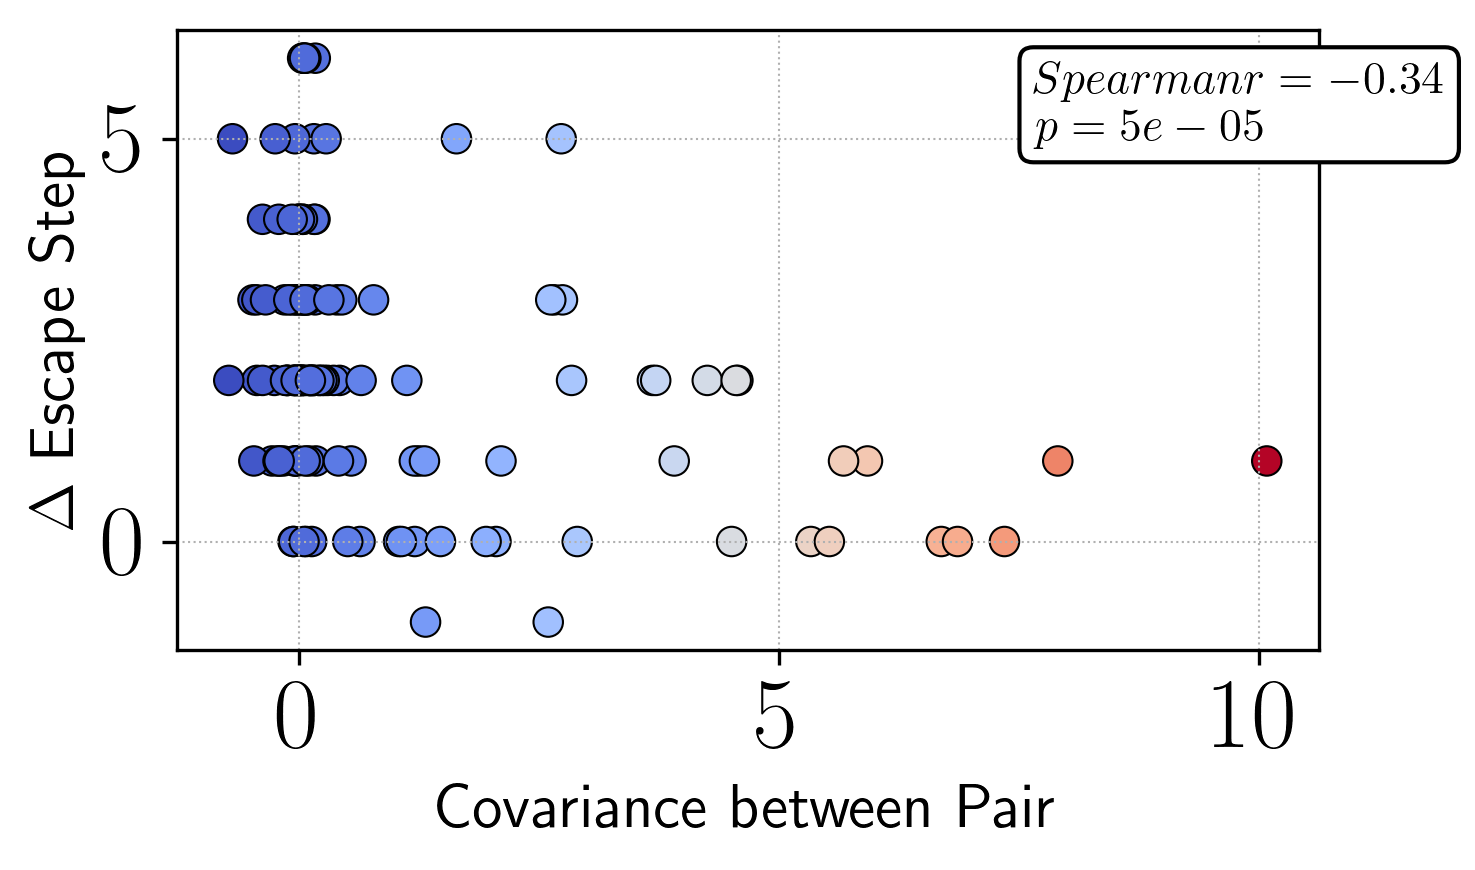

In [15]:


# --- Define covariance function ---
def covariance(x, y):
    """Compute sample covariance (same normalization as np.cov with bias=False)."""
    x_centered = x - np.mean(x)
    y_centered = y - np.mean(y)
    return np.dot(x_centered, y_centered) / (len(x) - 1)

# Data containers
covs = []
deltas = []
pair_labels = []

# Loop through cocktails to find all valid pairs
for cocktail_name, vals in delta_steps.items():
    
    # Get all antibodies in this cocktail
    abs_involved = list(vals['individual_steps'].keys())

    # Filter: Consider only pairs (exactly 2 antibodies)
    if len(abs_involved) != 2:
        continue

    ab1 = abs_involved[0]
    ab2 = abs_involved[1]

    # Get individual steps
    step1 = vals['individual_steps'][ab1]
    step2 = vals['individual_steps'][ab2]

    # Constraint: If one of the ab is never escaped (>= 10), discard the pair
    if step1 >= 10 or step2 >= 10:
        continue

    # Get indices for covariance calculation
    idx1 = ab_names.index(ab1)
    idx2 = ab_names.index(ab2)

    x = escapes[:, idx1]
    y = escapes[:, idx2]

    # Compute Covariance
    cov_value = covariance(x, y)
    
    # Compute Delta Escape
    # Logic: Cocktail Step - Best (Latest/Max) Single Step
    best_single_step = max(step1, step2)
    
    # Assuming vals has 'cocktail_step'. If your key is named differently, update here.
    cocktail_step = vals['cocktail_step'] 
    
    delta = cocktail_step - best_single_step

    covs.append(cov_value)
    deltas.append(delta)
    pair_labels.append(f"{ab1}+{ab2}")

# === Plot ===
fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

# Define a colormap
cmap = cm.get_cmap('coolwarm')

# Normalize covariances to [0, 1] for color mapping
if len(covs) > 0:
    cov_arr = np.array(covs)
    norm_covs = (cov_arr - np.min(cov_arr)) / (np.max(cov_arr) - np.min(cov_arr) + 1e-12)
    colors = cmap(norm_covs)
else:
    colors = 'blue'

# Scatter plot
ax.scatter(covs, deltas, color=colors, s=50, edgecolor='black', linewidth=0.5)

# Label points
# texts = [ax.text(covs[i], deltas[i], label, fontsize=8, ha='center') for i, label in enumerate(pair_labels)]
# adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", lw=0.5), force_text=(0.6, 0.9))

# Axis labels and title
ax.set_xlabel("Covariance between Pair", fontsize=15)
ax.set_ylabel(r"$\Delta$ Escape Step", fontsize=15)
ax.grid(True, linestyle=':', linewidth=0.5)

# Statistics
if len(covs) > 1:
    r, pval = spearmanr(covs, deltas)
    stat_text = fr"$Spearman r = {r:.2f}$" + "\n" + fr"$p = {pval:.3g}$"
    
    ax.text(0.75, 0.95, stat_text, transform=ax.transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

plt.tight_layout()
plt.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_4352\2378059293.py:62: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap('tab10')
C:\Users\maria\AppData\Local\Temp\ipykernel_4352\2378059293.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap('tab10')
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


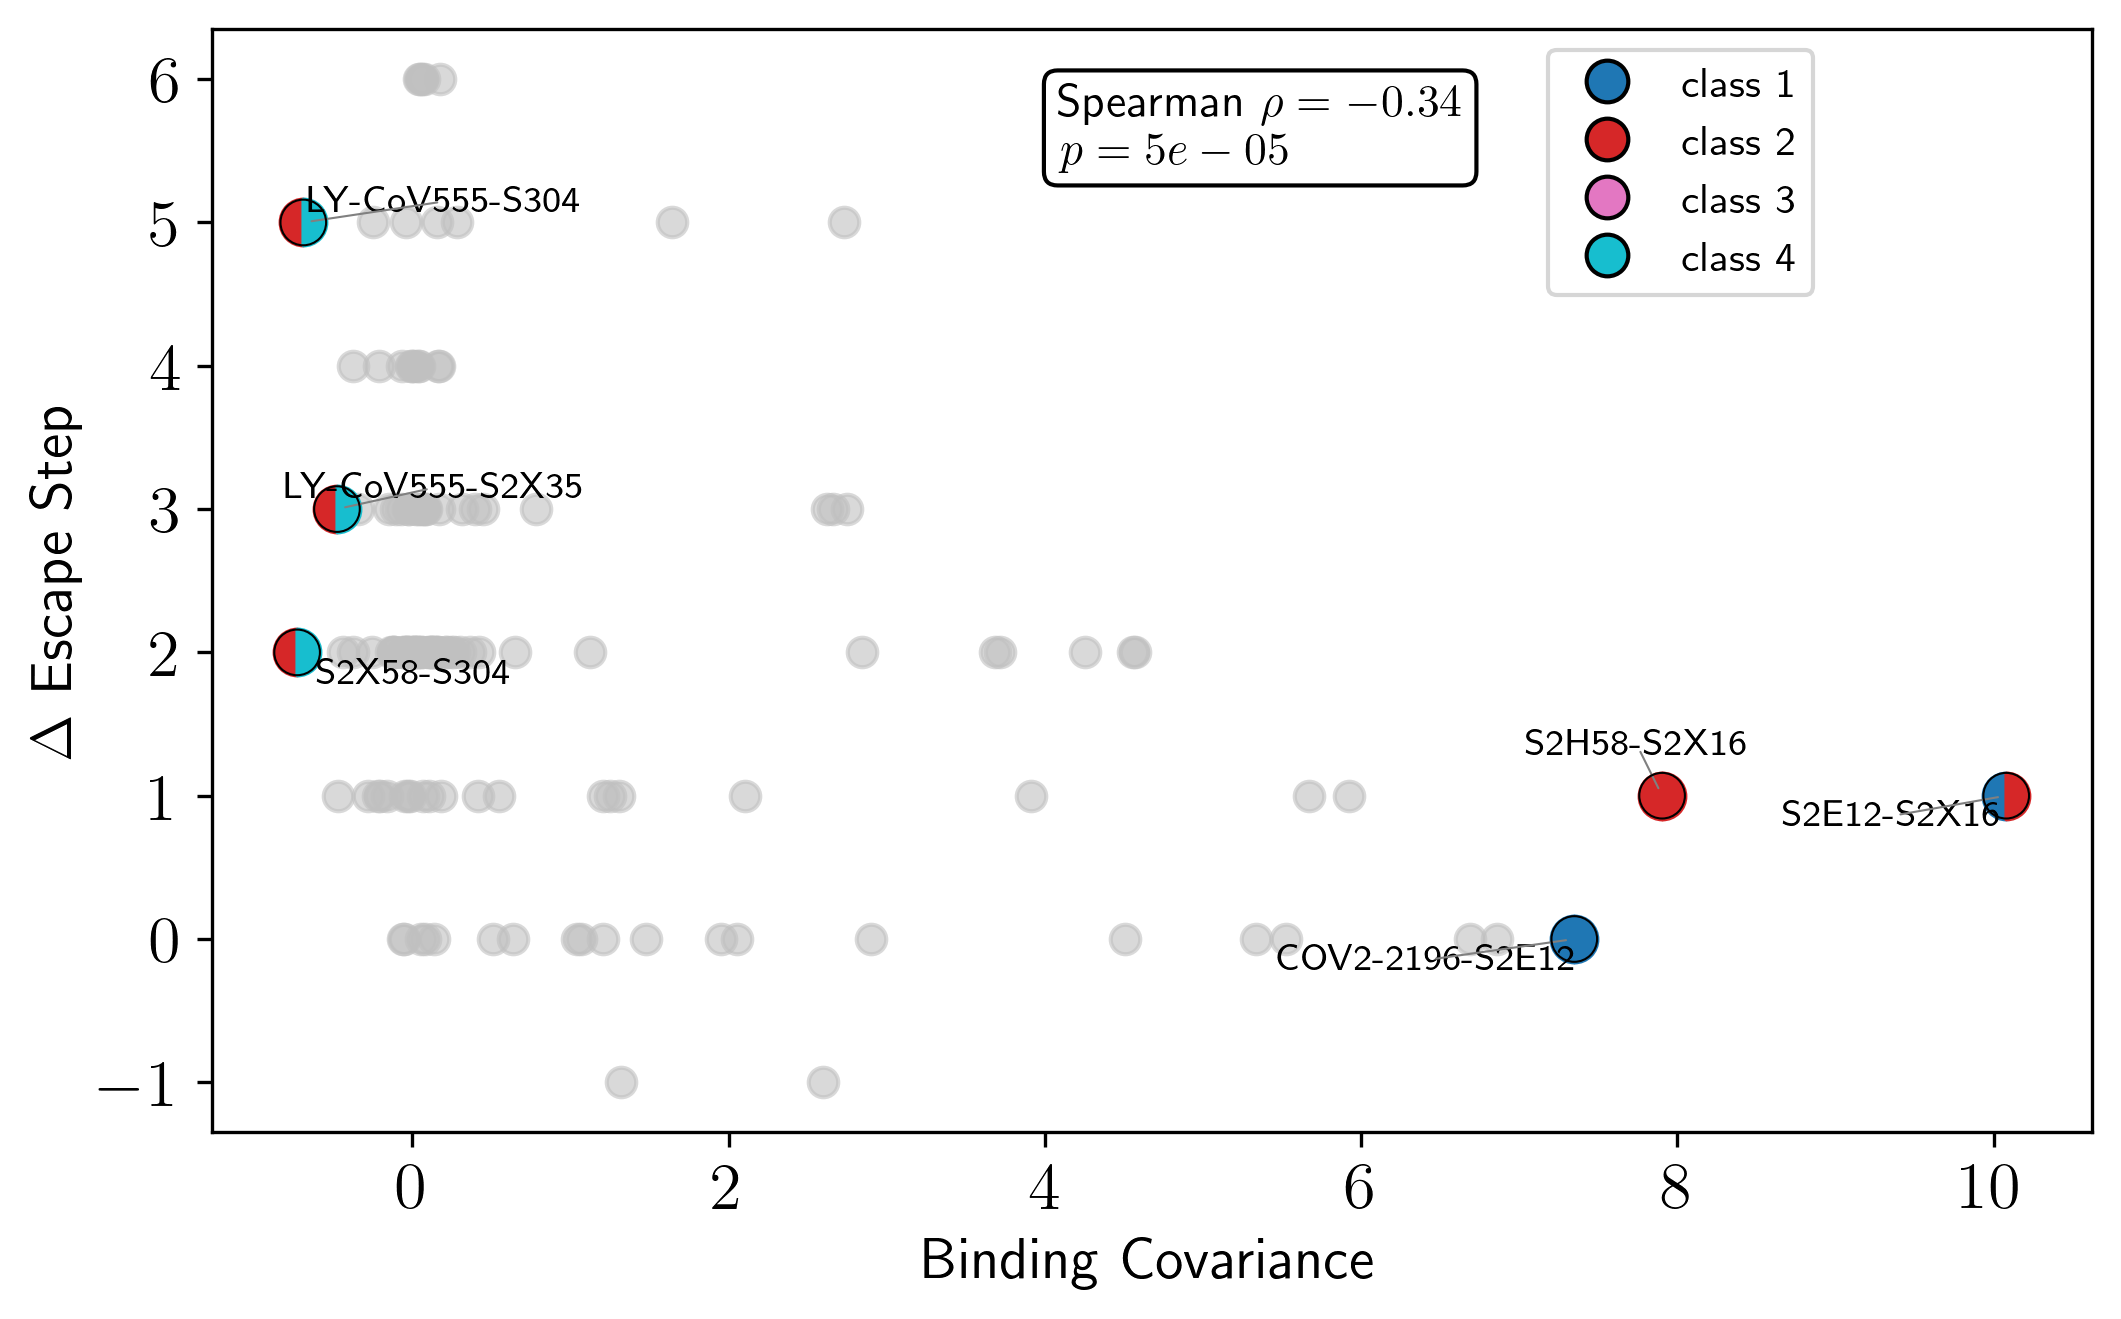

In [16]:


# --- 1. Define Helper Functions ---
def covariance(x, y):
    x_centered = x - np.mean(x)
    y_centered = y - np.mean(y)
    return np.dot(x_centered, y_centered) / (len(x) - 1)

# --- 2. Process Data ---
# Ensure class_mapping is defined, e.g.:


covs = []
deltas = []
pair_labels = []
pair_classes = [] # Stores tuple (class1, class2)
ab_pairs = []     # Stores tuple (ab1, ab2)

for cocktail_name, vals in delta_steps.items():
    abs_involved = list(vals['individual_steps'].keys())

    if len(abs_involved) != 2:
        continue

    ab1, ab2 = abs_involved[0], abs_involved[1]
    step1 = vals['individual_steps'][ab1]
    step2 = vals['individual_steps'][ab2]

    # Filter out if single Ab is not escaped
    if step1 >= 10 or step2 >= 10:
        continue

    # Covariance
    idx1 = ab_names.index(ab1)
    idx2 = ab_names.index(ab2)
    cov_value = covariance(escapes[:, idx1], escapes[:, idx2])
    
    # Delta Escape
    best_single_step = max(step1, step2)
    cocktail_step = vals['cocktail_step'] 
    delta = cocktail_step - best_single_step

    covs.append(cov_value)
    deltas.append(delta)
    pair_labels.append(f"{ab1}-{ab2}")
    ab_pairs.append((ab1, ab2))
    
    c1 = class_mapping.get(ab1, 'Unknown')
    c2 = class_mapping.get(ab2, 'Unknown')
    pair_classes.append((c1, c2))

# Convert to numpy for easier indexing
covs = np.array(covs)
deltas = np.array(deltas)
pair_labels = np.array(pair_labels)
pair_classes = np.array(pair_classes, dtype=object)

# --- 3. Determine Colors ---
unique_classes = sorted(list(set([c for p in pair_classes for c in p])))
n_classes = len(unique_classes)

# Create color mapping
if n_classes <= 10:
    cmap_obj = cm.get_cmap('tab10')
    class_colors = [cmap_obj(i) for i in range(n_classes)]
    #replace with colors = plt.colormaps['tab10'](np.linspace(0, 1, n_classes))

if n_classes > 0:
    cmap_obj = cm.get_cmap('tab10')
    class_colors = cmap_obj(np.linspace(0, 1, n_classes))
else:
    class_colors = []
color_map = dict(zip(unique_classes, class_colors))

# --- 4. Identify Top and Bottom 5 ---
# Sort by Delta
sorted_indices = np.argsort(covs)
bottom_5_idx = sorted_indices[:3]
top_5_idx = sorted_indices[-3:]

# Combine indices to annotate
annotate_indices = np.concatenate([bottom_5_idx, top_5_idx])

# --- 5. Plot ---
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=300)

# A. Plot ALL points as neutral background
ax.scatter(covs, deltas, color='silver', s=50, alpha=0.6, label='_nolegend_')

# B. Highlight and Annotate Top/Bottom 5
texts = []
for idx in annotate_indices:
    x = covs[idx]
    y = deltas[idx]
    c1_name, c2_name = pair_classes[idx]
    col1 = color_map[c1_name]
    col2 = color_map[c2_name]
    
    # Plot Split Marker (Left = Class 1, Right = Class 2)
    ax.scatter(x, y, color=col1, s=120, marker=MarkerStyle('o', fillstyle='left'), zorder=3)
    ax.scatter(x, y, color=col2, s=120, marker=MarkerStyle('o', fillstyle='right'), zorder=3)
    # Add outline
    ax.scatter(x, y, facecolors='none', edgecolors='black', s=120, linewidth=0.5, zorder=4)
    
    # Add label
    # Note: Multi-colored text strings are complex in Matplotlib. 
    # We color the text black for readability, relying on the marker for class info.
    t = ax.text(x, y, pair_labels[idx], fontsize=9, ha='center', color='black')
    texts.append(t)

# C. Adjust Text positions
adjust_text(texts, ax=ax, 
            arrowprops=dict(arrowstyle="-", color='gray', lw=0.5),
            force_text=(1.2, 1.2),    # Increase repulsion between text labels (default ~0.1)
            force_points=(0.5, 0.8),  # Increase repulsion between text and points
            expand_points=(1.5, 1.5), # "Inflate" points so text stays further away
            lim=1000                  # Allow more iterations to find a solution
)
# D. Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=cls_name,
           markerfacecolor=col, markersize=10, markeredgecolor='black')
    for cls_name, col in color_map.items()
]
ax.legend(handles=legend_elements, bbox_to_anchor=(.7, 1), loc='upper left', fontsize=10)

# E. Formatting
ax.set_xlabel("Binding Covariance", fontsize=14)
ax.set_ylabel(r"$\Delta$ Escape Step", fontsize=14)
# ax.grid(True, linestyle=':', alpha=0.6)
ax.tick_params(axis='both', labelsize=16)
# F. Stats
if len(covs) > 1:
    r, pval = spearmanr(covs, deltas)
    stat_text = fr"Spearman $\rho = {r:.2f}$" + "\n" + fr"$p = {pval:.3g}$"
    ax.text(0.45, 0.95, stat_text, transform=ax.transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
# plt.ylim(-1,10)
plt.tight_layout()
plt.show()